---
# Exemples de conception de pipelines de traitement des données
### Auteur: Pierre Gravel <pierre.gravel@iid.ulaval.ca>
### Institut intelligence et données (IID), Québec, Canada
### License: BSD
---

<p>&nbsp;</p>
<div align="center">
    <img src= "./images/pipeline-photo4.jpeg"  width="400" />
    <div>
    <font size="1.5">Image Source: http://www.brpetro.com/syllpx/</font>
    </div>
</div>
<p>&nbsp;</p>

Dans ce tutoriel, nous allons voir comment concevoir des pipelines de traitement des données pour la classifications d'images. 

# Table des matières
1. Introduction
2. Premier pipeline
    1. Définition du pipeline
    2. Entraînement du pipeline avec les données d'entraînement
    3. Évaluation de ses performances en classification sur l'ensemble de test
3. Deuxième pipeline
    1. Définition du pipeline
    2. Définition de la recherche sur grille
    3. Entraînement du pipeline avec chaque combinaison de paramètres
    4. Affichage des paramètres du pipeline optimal
4. Troisième pipeline
    1. Définition du pipeline
    2. Définition de la recherche sur grille
    3. Entraînement du pipeline avec chaque combinaison de paramètres
    4. Affichage des paramètres du pipeline optimal
5. Diviser pour conquérir
6. Leçons à retenir

#### Importation des librairies utilisées.

In [1]:
import os
import sys
import warnings

import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets, decomposition
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import QuantileTransformer, StandardScaler
from sklearn.svm import SVC
from sklearn import set_config
set_config(display="text")

# Élimination des avertissements (warnings).
# Utile lorsque certains modèles ne convergent pas pendant la recherche d'hyperparamètres.
if not sys.warnoptions:
    warnings.simplefilter("ignore")
    os.environ["PYTHONWARNINGS"] = "ignore"

# Définition du seed pour assurer la reproductibilité
seed = 42
rng_seed = seed

## Introduction

Dans les modules précédents consacrés au prétraitement des données, nous avons vu les différentes étapes de nettoyage, d'imputation des données manquantes, de normalisation, etc.

Dans chaque cas, l'étape était étudiée séparément, hors d'un contexte global, afin d'apprendre à l'utiliser dans des situations précises. Une fois que l'on maîtrise chacune de ces étapes, il devient intéressant de pouvoir en combiner plusieurs, voire toutes, afin d'élaborer un processus de prétraitement plus spécialisé.

Imaginons un projet dans lequel il faudrait effectuer chacune des opérations de prétraitement de la figure suivante avant même de passer à la phase de classification (régression, regroupement de données, etc.).
Il nous faudrait optimiser chacune des étapes en tenant compte des autres afin de maximiser les performances de notre application finale.

<p>&nbsp;</p>
<div align="center">
    <img src= "./images/data-processing.png"  width="500" />
    <div>
    <font size="1.5">Image Source: http://pzs.dstu.dp.ua/DataMining/preprocessing/bibl/Data%20Preprocessing%20in%20Data%20Mining.pdf/</font>
    </div>
</div>
<p>&nbsp;</p>

C'est exactement ce que permet de faire la conception et l'optimisation d'un pipeline d'analyse de données ! La plupart des projets devraient passer par cette étape. Elle est efficace pour la gestion et le développement d'un projet complexe. Idéalement, on ne devrait modifier que quelques sections d'un pipeline pour tester une nouvelle idée ou implémenter un nouvel algorithme d'analyse. Il n'est pas nécessaire de recommencer un nouveau programme à chaque fois ; une fois la roue inventée, il suffit de la pousser dans une nouvelle direction.

Le concept de pipeline d'analyse des données est l'un des joyaux de la bibliothèque Scikit-learn. Nous allons apprendre à en construire plusieurs et à les optimiser pour une tâche donnée. Un pipeline simplifie considérablement la tâche des programmeurs. Apprenez à les utiliser !

#### Lecture des données

Nous allons utiliser à nouveau un sous-ensemble du jeu de données
[**MNIST**](https://en.wikipedia.org/wiki/MNIST_database)
qui comprend des images de chiffres 0 à 9 de taille $8 \text{ par } 8$. Les images du jeu de données original sont de taille $28 \text{ par } 28$. Nous allons n'utiliser que les images des chiffres 0 à 5.

In [2]:
# Lecture du jeu de données et séparation en train/test
digits = datasets.load_digits(n_class=6)
X = digits.data
y = digits.target

# Informations utiles pour le tutoriel
print(f"Dimensions du jeu de données : {X.shape}")
print(f"Nombre de classes : {len(np.unique(y))}")

# Séparation en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=rng_seed
)


Dimensions du jeu de données : (1083, 64)
Nombre de classes : 6


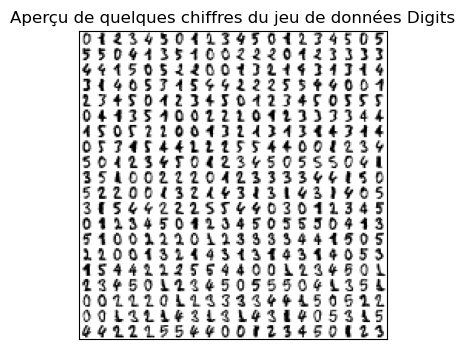

In [3]:
# Affichage de quelques images du dataset Digits
n_img_per_row = 20
img = np.zeros((10 * n_img_per_row, 10 * n_img_per_row))

for i in range(n_img_per_row):
    ix = 10 * i + 1
    for j in range(n_img_per_row):
        iy = 10 * j + 1
        img[ix : ix + 8, iy : iy + 8] = X[i * n_img_per_row + j].reshape((8, 8))

plt.figure(figsize=(4, 4))
plt.imshow(img, cmap=plt.cm.binary)
plt.title("Aperçu de quelques chiffres du jeu de données Digits")
plt.xticks([])
plt.yticks([])
plt.show()

## Premier pipeline

<p>&nbsp;</p>
<div align="center">
    <img src= "./images/pipeline-photo.jpeg"  width="400" />
    <div>
    <font size="1.5">Image Source: https://www.bdcmagazine.com/2020/08/the-importance-of-pipeline-repair-services//</font>
    </div>
</div>
<p>&nbsp;</p>

Comme premier essai, construisons un pipeline de base combinant deux étapes de prétraitement, suivie d'une étape
de classification. On utilise ici un classificateur de type
[SVM](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html).
Le type de classificateur n'est pas vraiment important dans cette série d'exemples. D'ailleurs, il
recommandé d'en essayer plusieurs lors d'un projet et de choisir le meilleur parmi eux. Dans le cas du classificateur SVM,
il a deux hyperparamètres à ajuster: $\alpha$ et $C$.

Nous allons effectuer les étapes suivantes:

- normalisation standard,
- réduction de la dimensionnalité des données (PCA),
- classification avec la méthode SVM. 

Chaque opération utilisera ses paramètres par défaut ou ceux spécifiés dans l'appel de la fonction.

### Définition du pipeline

Les noms utilisés dans la définition du pipeline (par exemple « transformation », « reduce_dim » ou « classify ») sont arbitraires. Vous pouvez les changer, mais veillez à ce qu'ils soient plus significatifs que « testA », « Bozo », etc.

Après chaque nom apparaît le nom de l'opérateur associé, par exemple [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler) qui effectue la normalisation standard. Puis, apparaissent les hyperparamètres sélectionnés, différents de ceux par défaut de chaque opérateur.

L'opérateur de réduction de dimensionnalité indique que seules les deux premières composantes sont conservées après la transformation en composantes principales. 

L'opérateur de classification SVC indique qu'on utilise un classificateur de type SVM avec quatre hyperparamètres d'initialisation.

N. B. : les détails des méthodes [SVM](https://scikit-learn.org/stable/modules/svm.html) et [PCA](https://scikit-learn.org/stable/modules/decomposition.html) ne sont pas essentiels pour comprendre les notions vues dans ce tutoriel.

In [4]:
# Définition du pipeline StandardScaler → PCA → SVC
pipeline = Pipeline(
    [
        ("transformation", StandardScaler()),
        ("reduce_dim", PCA(n_components=2, random_state=seed)),
        ("classify", SVC(kernel="rbf", C=1, gamma=0.2, max_iter=1000)),
    ]
)

print(pipeline)

Pipeline(steps=[('transformation', StandardScaler()),
                ('reduce_dim', PCA(n_components=2, random_state=42)),
                ('classify', SVC(C=1, gamma=0.2, max_iter=1000))])


### Entraînement du pipeline avec les données d'entraînement

In [5]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('transformation', StandardScaler()),
                ('reduce_dim', PCA(n_components=2, random_state=42)),
                ('classify', SVC(C=1, gamma=0.2, max_iter=1000))])

#### Important

Si l'on désire traiter un nouvel ensemble de données `X_new`, il ne reste plus qu'à faire ceci:

```python
y_pred = pipeline.predict(X_new)
```

Si l'on désire calculer le score associé, on fait ceci:

```python
score = pipeline.score(X_new, y_new)
```

### Évaluation de ses performances en classification sur l'ensemble de test

En classification, le score par défaut est l'exactitude (*accuracy*) qui correspond à la proportion de bonnes prédictions effectuées.

In [6]:
print("\nScore en entraînement: %0.1f %%" % (100 * pipeline.score(X_train, y_train)))
print("\nScore en test: %0.1f %%" % (100 * pipeline.score(X_test, y_test)))


Score en entraînement: 79.9 %

Score en test: 83.8 %


## Deuxième pipeline


<p>&nbsp;</p>
<div align="center">
    <img src= "./images/pipeline-photo2.jpeg"  width="400" />
    <div>
    <font size="1.5">Image Source: https://pxhere.com/en/photo/1081470/</font>
    </div>
</div>
<p>&nbsp;</p>

Supposons maintenant qu'on ne soit pas certain que la normalisation standard soit la meilleure méthode de
transformation des données. On aimerait en tester au moins deux:


- normalisation standard,
- transformation par les quantiles ([QuantileTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.QuantileTransformer.html#sklearn.preprocessing.QuantileTransformer)).


On voudrait garder inchangées les étapes précédentes de redimensionnement et de classification.

### Définition du pipeline

Puisqu'il y a deux méthodes de transformation de données, la grille des paramètres suivante contient deux dictionnaires de paramètres. On peut ainsi considérer qu'il y a deux mini pipelines; un pour chaque méthode de transformation. On procède en utilisant le mot clé `'passthrough'` qui permet de spécifier chacun des choix à essayer pour l'étape de transformation des données.

In [7]:
pipeline = Pipeline(
    [
        ("transformation", "passthrough"),
        ("reduce_dim", decomposition.PCA(n_components=2)),
        ("classify", SVC(kernel="rbf", C=1, gamma=0.2, max_iter=1000)),
    ]
)

# Grille des paramètres à modifier. le mot clé passthrough renvoie ici
param_grid = [
    {"transformation": [StandardScaler()]},
    {"transformation": [QuantileTransformer(output_distribution="normal", n_quantiles=50)]},
]

Il faut maintenant tester les deux mini pipelines afin de trouver le plus performant des deux. Pour
cela, on utilisera la fonction
[`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html#sklearn.model_selection.GridSearchCV.predict)
qui permet d'effectuer une recherche sur une grille d'hyperparamètres qui sont
dans ce cas-ci les deux méthodes de transformation.

<p>&nbsp;</p>
<div align="center">
    <img src= "./images/light-bulb-idea.jpeg"  width="200" />
    <div>
    <font size="0.5">Image Source: https://basementdesigner.com/basement-finishing-102/light-bulb-idea//</font>
    </div>
</div>

`GridSearchCV` procède par validation croisée sur l'ensemble d'entraînement. Les principes de la validation
croisée ont été expliqués pendant la formation. En gros, elle permet de choisir le plus performant parmi
plusieurs modèles, dans ce cas-ci, entre les deux mini pipelines.

Enfin, `GridSearchCV` réentraîne le pipeline optimal en utilisant cette fois-ci **toutes** les données
d'entraînement, sans validation croisée.


Si l'on désire traiter un nouvel ensemble de données `X_new`, il ne reste plus qu'à faire ceci:


```python
y_pred = grid_search.predict(X_new)
```

Si l'on désire calculer le score associé, on fait ceci:

```python
score = grid_search.score(X_new, y_new)
```

### Définition de la recherche sur grille

In [8]:
grid_search = GridSearchCV(
    pipeline, param_grid=param_grid, n_jobs=2, verbose=1, refit=True
)

### Entraînement du pipeline avec chaque combinaison de paramètres

L'affichage qui suit indique que 10 *fits* (entraînement) ont été effectués. Il y avait 2 modèles à
tester et 5 repliements pour chacun lors de la validation croisée, soit un total de 10 entraînements.

In [9]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 2 candidates, totalling 10 fits


GridSearchCV(estimator=Pipeline(steps=[('transformation', 'passthrough'),
                                       ('reduce_dim', PCA(n_components=2)),
                                       ('classify',
                                        SVC(C=1, gamma=0.2, max_iter=1000))]),
             n_jobs=2,
             param_grid=[{'transformation': [StandardScaler()]},
                         {'transformation': [QuantileTransformer(n_quantiles=50,
                                                                 output_distribution='normal')]}],
             verbose=1)

### Affichage des paramètres du pipeline optimal

Définissons une fonction permettant d'afficher les paramètres.

In [10]:
def afficheMeilleurChoixParametres(grid_search):
    print("\nMeilleur choix de paramètres:")
    steps = dict(grid_search.best_estimator_.steps)

    for param_name in sorted(steps.keys()):
        print("\t%s: %r" % (param_name, steps[param_name]))

    print("\nScore optimal en entraînement: %0.1f %%" % (100 * grid_search.best_score_))
    print(
        "\nScore en test avec le pipeline optimal: %0.1f %%\n"
        % (100 * grid_search.score(X_test, y_test))
    )

In [11]:
afficheMeilleurChoixParametres(grid_search)


Meilleur choix de paramètres:
	classify: SVC(C=1, gamma=0.2, max_iter=1000)
	reduce_dim: PCA(n_components=2)
	transformation: StandardScaler()

Score optimal en entraînement: 78.3 %

Score en test avec le pipeline optimal: 83.8 %



## Troisième pipeline

<p>&nbsp;</p>
<div align="center">
    <img src= "./images/pipeline-photo3.jpeg"  width="400" />
    <div>
    <font size="1.5">Image Source: https://www.wallpaperflare.com/search?wallpaper=pipeline/</font>
    </div>
</div>
<p>&nbsp;</p>

Se pourrait-il que le choix précédent de la normalisation standard, par rapport à l'autre méthode de transformation, ait
été influencé par les valeurs des paramètres des deux autres opérations? C'est très pertinent
comme question. On va le vérifier.

On va optimiser à nouveau le pipeline en faisant varier les facteurs suivants:


- Transformation:
   - normalisation standard,
   - transformation par les quantiles (`QuantileTransformer`). 
- Réduction de la dimensionnalité:
    - `n_components` $= [2, 8, 32]$
- Classificateur SVM:
    - `C` $= [0.1, 1, 10, 100]$,
    - `gamma` $= [0.001, 0.01, 0.1, 1]$.

### Définition du pipeline

Puisqu'il y a à nouveau deux méthodes de transformation de données, la grille des paramètres suivante contient deux dictionnaires de paramètres. Il y a encore deux mini pipelines.

In [12]:
pipeline = Pipeline(
    [
        ("transformation", "passthrough"),
        ("reduce_dim", decomposition.PCA()),
        ("classify", SVC(kernel="rbf", max_iter=1000)),
    ]
)

param_grid = [
    {
        "transformation": [StandardScaler()],
        "reduce_dim__n_components": [2, 8, 32],
        "classify__C": [0.1, 1, 10, 100],
        "classify__gamma": [0.001, 0.01, 0.1, 1],
    },
    {   "transformation": [QuantileTransformer(output_distribution="normal", n_quantiles=50)],
        "reduce_dim__n_components": [2, 8, 32],
        "classify__C": [0.1, 1, 10, 100],
        "classify__gamma": [0.001, 0.01, 0.1, 1],
    },
]

### Définition de la recherche sur grille

In [13]:
grid_search = GridSearchCV(
    pipeline, param_grid=param_grid, n_jobs=2, verbose=1, refit=True
)

### Entraînement du pipeline avec chaque combinaison de paramètres

L'affichage qui suit indique que 480 entraînements ont été effectués. Il y avait 2 modèles à tester, $3 \times 4 \times 4 = 48$
combinaisons d'hyperparamètres pour chacun, et 5 repliements pour chacun lors de la validation croisée,
soit un total de $2\times 48\times 5= 480$ entraînements.

> Prends un peu de temps à être exécuter étant donné qu'il y a 480 entraînements à faire.

In [14]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 96 candidates, totalling 480 fits


GridSearchCV(estimator=Pipeline(steps=[('transformation', 'passthrough'),
                                       ('reduce_dim', PCA()),
                                       ('classify', SVC(max_iter=1000))]),
             n_jobs=2,
             param_grid=[{'classify__C': [0.1, 1, 10, 100],
                          'classify__gamma': [0.001, 0.01, 0.1, 1],
                          'reduce_dim__n_components': [2, 8, 32],
                          'transformation': [StandardScaler()]},
                         {'classify__C': [0.1, 1, 10, 100],
                          'classify__gamma': [0.001, 0.01, 0.1, 1],
                          'reduce_dim__n_components': [2, 8, 32],
                          'transformation': [QuantileTransformer(n_quantiles=50,
                                                                 output_distribution='normal')]}],
             verbose=1)

### Affichage des paramètres du pipeline optimal

In [15]:
afficheMeilleurChoixParametres(grid_search)


Meilleur choix de paramètres:
	classify: SVC(C=10, gamma=0.01, max_iter=1000)
	reduce_dim: PCA(n_components=32)
	transformation: StandardScaler()

Score optimal en entraînement: 99.5 %

Score en test avec le pipeline optimal: 98.9 %



Le score en test est passé de $83,8~\%$ à $98,9~\%$!

**Remarque!** : testez différentes combinaisons de classificateurs et de nombres de composantes pour la réduction de la dimensionnalité. Essayez d'obtenir un score de test supérieur. Attention toutefois à ne pas tester trop de combinaisons, car le temps de calcul peut être assez long.

## Diviser pour conquérir

Bien qu'il soit pratique de nettoyer ses données et de les classifier dans un même pipeline, c'est rarement la meilleure stratégie.

Vous devriez plutôt utiliser un pipeline pour trouver la bonne méthode de prétraitement puis l'implémenter.
Ça vous permettrait de vous concentrer ensuite sur la partie la plus intéressante de votre projet c.-à-d. la
classification, la régression, etc. 

Créez un second pipeline pour traiter cette nouvelle partie d'un projet. Inutile de refaire le prétraitement des données à chaque fois.

## Leçons à retenir

<p>&nbsp;</p>
<div align="center">
    <img src= "./images/architect-businessman.jpeg"  width="300" />
    <div>
    <font size="1.5">Image Source: https://www.wallpaperflare.com/search?wallpaper=pipeline/</font>
    </div>
</div>
<p>&nbsp;</p>



Un pipeline garantit:
1. **La reproductibilité**
    1. Le pipeline enregistre toutes les étapes et tous les paramètres (scaling, imputation, modèle, etc.) dans un seul objet.
    2. On peut relancer l’expérience demain, sur une autre machine, ou dans un autre notebook : on obtient exactement le même comportement.


2. **L'absence de fuite d’information** (*data leakage*)
    1. Chaque transformation (*fit*) est faite uniquement sur les données d’entraînement, jamais sur le test.
    2. C’est la garantie la plus importante en apprentissage automatique.


3. **La cohérence entre entraînement et prédiction**
    1. Les mêmes transformations sont appliquées dans le même ordre, avec les mêmes paramètres, lorsque l’on veut faire une prédiction sur de nouvelles données (*predict*).
    2. Le modèle reçoit toujours des données transformées de manière identique.


4. **La compatibilité totale avec GridSearchCV et la validation croisée**
    1. GridSearchCV peut tester des hyperparamètres du modèle et du prétraitement.
    2. Toutes les étapes sont correctement ré entraînées à chaque fold de CV.
    3. Aucun risque de fuite ou d’incohérence.